# e3vote Benchmark Comparison

Compare multiple benchmark runs side-by-side (e.g., different chain gas limits).

**Usage:** Edit the `RUNS` list below to point to your benchmark output directories.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path
from matplotlib.patches import Patch

plt.rcParams.update({
    'font.size': 11,
    'font.family': 'serif',
    'figure.figsize': (7, 4),
    'figure.dpi': 150,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

# --- CONFIGURE RUNS TO COMPARE ---
# (path, label, gas_limit)
RUNS = [
    (Path('benchmarks/4s_gas30'), '30M gas limit'),
    (Path('benchmarks/10s_gas300'), '300M gas limit'),
    # (Path('benchmarks/run_20260509_163259'), '600M gas limit'),
]

# Ballot casting cost model
VOTE_GAS_COST = 1_197_646

OUTPUT_DIR = Path('benchmarks/comparison_output')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
# --- DATA LOADING ---
combined_df = pd.DataFrame()
combined_results = []

for run_dir, label in RUNS:
    csv_path = run_dir / 'votes.csv'
    json_path = run_dir / 'results.json'

    if not csv_path.exists() or not json_path.exists():
        print(f"WARNING: Skipping '{label}' — missing files in {run_dir}")
        continue

    df = pd.read_csv(csv_path)
    df['run'] = label

    with open(json_path) as f:
        results = json.load(f)
    results['_label'] = label
    results['_dir'] = str(run_dir)
    results['_gas_limit'] = results['metadata']['blockGasLimit']

    combined_df = pd.concat([combined_df, df], ignore_index=True)
    combined_results.append(results)

print(f"Loaded {len(combined_results)} run(s), {len(combined_df)} total vote records")
for r in combined_results:
    meta = r['metadata']
    print(f"  [{r['_label']}] {meta['timestamp'][:19]}, "
          f"gas limit: {r['_gas_limit']:,}, "
          f"scale points: {[sp['voters'] for sp in r['scalePoints']]}")

# Color palette
COLORS = plt.cm.tab10.colors
RUN_COLORS = {label: COLORS[i % len(COLORS)] for i, (_, label) in enumerate(RUNS)}
run_labels = [r['_label'] for r in combined_results]
n_runs = len(run_labels)


Loaded 2 run(s), 164348 total vote records
  [30M gas limit] 2026-05-11T14:42:46, gas limit: 30,294,244, scale points: [500, 1000, 2000, 5000]
  [300M gas limit] 2026-05-11T11:45:04, gas limit: 301,762,100, scale points: [500, 1000, 2000, 5000]


/tmp/ipykernel_12246/2761317541.py:13: DtypeWarning: Columns (11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_12246/2761317541.py:13: DtypeWarning: Columns (11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


## 1. Throughput (TPS) Comparison

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


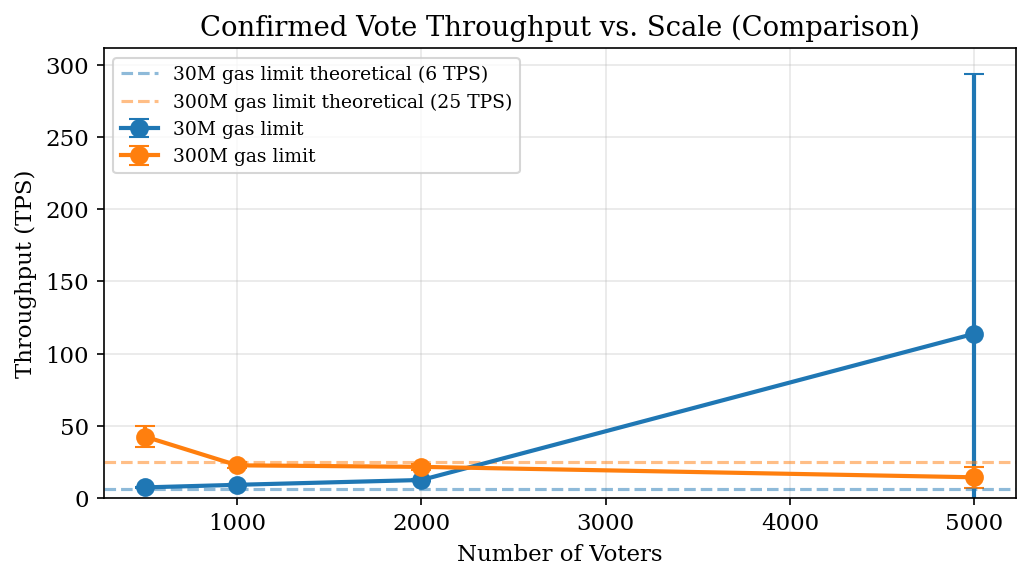

In [3]:
fig, ax = plt.subplots()

# Plot measured TPS
for r in combined_results:
    label = r['_label']
    color = RUN_COLORS[label]
    tps_data = []
    for sp in r['scalePoints']:
        agg = sp.get('aggregated', {}).get('tps', {})
        if agg:
            tps_data.append({'voters': sp['voters'], 'mean': agg['mean'], 'ci95': agg['ci95']})
    if tps_data:
        tps_df = pd.DataFrame(tps_data)
        ax.errorbar(tps_df['voters'], tps_df['mean'], yerr=tps_df['ci95'],
                    fmt='o-', capsize=5, color=color, linewidth=2, markersize=8, label=label)

# Plot theoretical throughput: h/t where h = gas_limit / VOTE_GAS_COST
for r in combined_results:
    gas_limit = r['_gas_limit']
    slot_time = r['metadata']['slotTimeS']
    h = int(gas_limit / VOTE_GAS_COST)
    theoretical_tps = h / slot_time
    ax.axhline(theoretical_tps, color=RUN_COLORS[r['_label']], linestyle='--', alpha=0.5,
              label=f'{r["_label"]} theoretical ({theoretical_tps:.0f} TPS)')

ax.set_xlabel('Number of Voters')
ax.set_ylabel('Throughput (TPS)')
ax.set_title('Confirmed Vote Throughput vs. Scale (Comparison)')
ax.set_ylim(bottom=0)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_tps_comparison.eps', format='eps')
plt.show()


## 1b. Theoretical vs Experimental Casting Time
Theoretical time to cast N votes: \/h\$ where \$ = voters, \$ = slot time, \$ = votes per block.

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


25
251


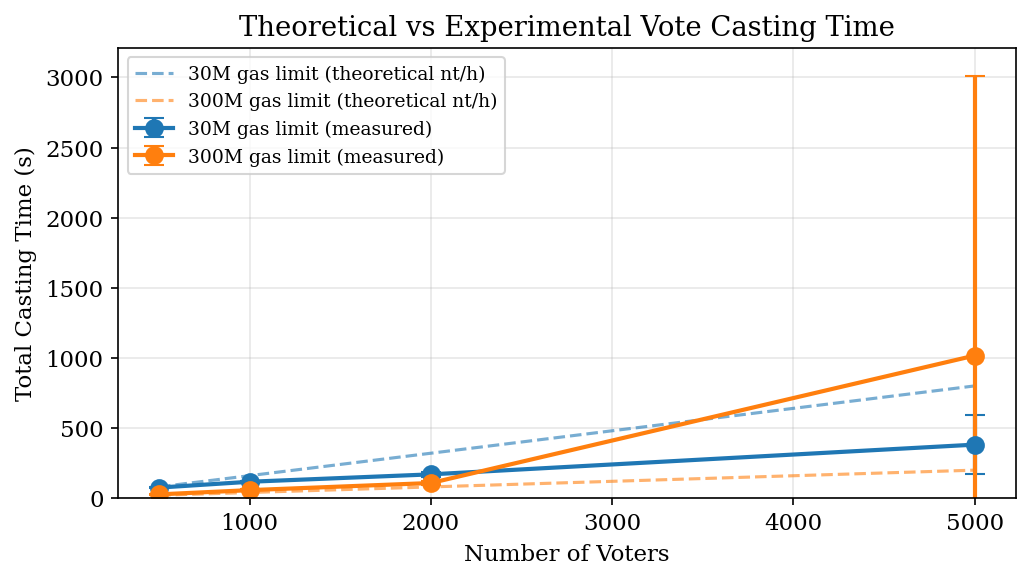

In [4]:
fig, ax = plt.subplots()

for r in combined_results:
    label = r['_label']
    color = RUN_COLORS[label]
    gas_limit = r['_gas_limit']
    slot_time = r['metadata']['slotTimeS']
    h = int(gas_limit / VOTE_GAS_COST)
    print(h)
    voters_list, exp_means, exp_stds, theo_times = [], [], [], []
    for sp in r['scalePoints']:
        n = sp['voters']
        reps = [rep['voteTimeS'] for rep in sp['repetitions']]
        voters_list.append(n)
        exp_means.append(np.mean(reps))
        exp_stds.append(np.std(reps))
        theo_times.append(n * slot_time / h)

    ax.errorbar(voters_list, exp_means, yerr=exp_stds,
                fmt='o-', capsize=5, color=color, linewidth=2, markersize=8, label=f'{label} (measured)')
    ax.plot(voters_list, theo_times,
            '--', color=color, alpha=0.6, label=f'{label} (theoretical nt/h)')

ax.set_xlabel('Number of Voters')
ax.set_ylabel('Total Casting Time (s)')
ax.set_title('Theoretical vs Experimental Vote Casting Time')
ax.set_ylim(bottom=0)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_casting_time_theoretical.eps', format='eps')
plt.savefig(OUTPUT_DIR / 'fig_casting_time_theoretical.png', dpi=150)
plt.show()


## 2. Timing Decomposition Comparison

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


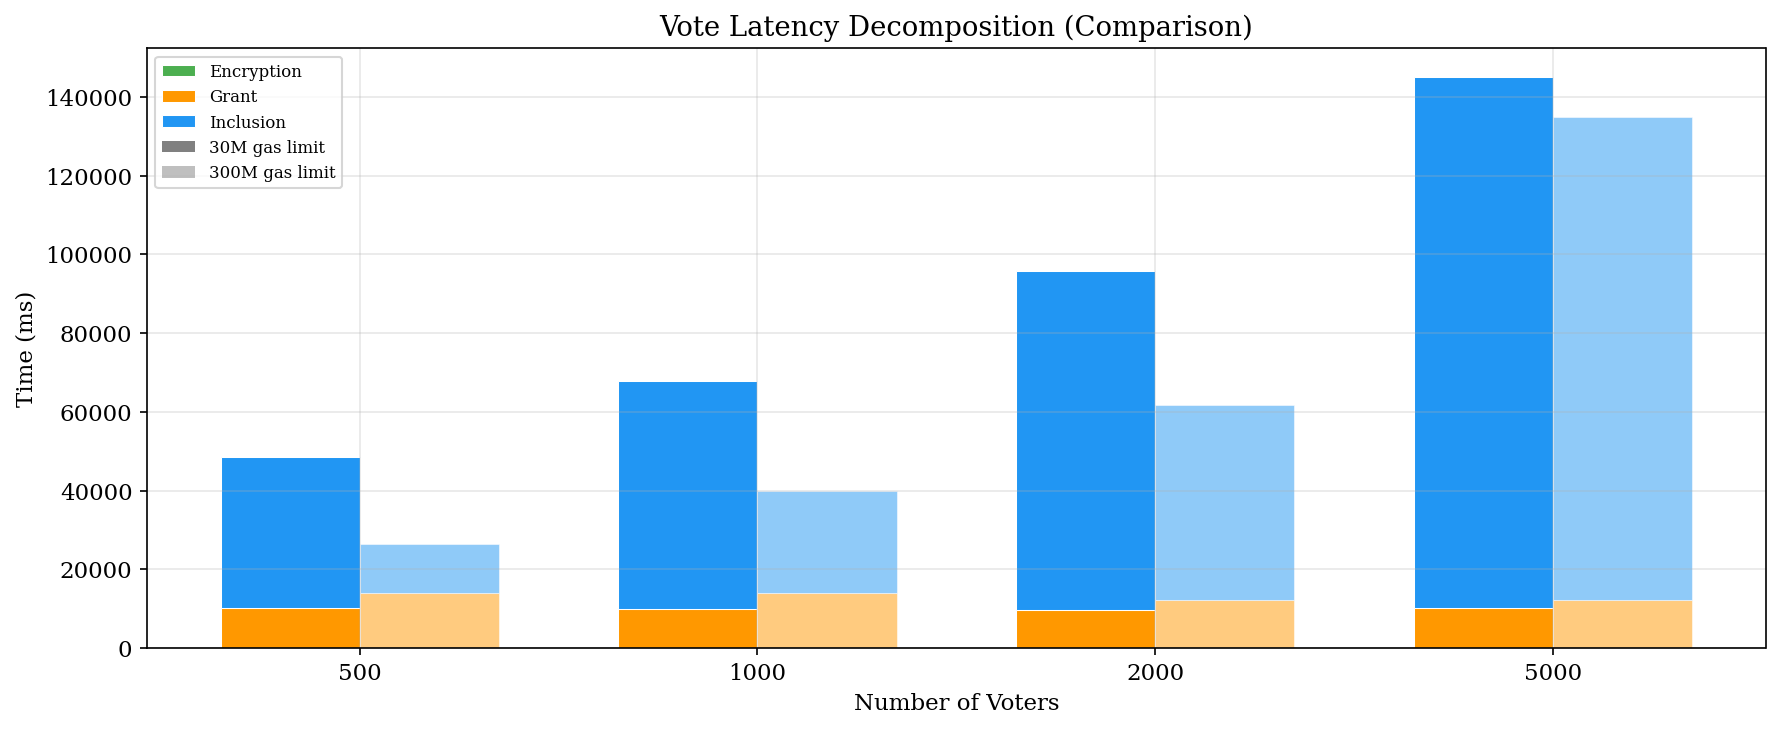

In [5]:
timing_cols = ['encrypt_time_ms', 'grant_time_ms', 'inclusion_delay_ms']
labels_map = {'encrypt_time_ms': 'Encryption', 'grant_time_ms': 'Grant', 'inclusion_delay_ms': 'Inclusion'}
phase_colors = {'encrypt_time_ms': '#4CAF50', 'grant_time_ms': '#FF9800', 'inclusion_delay_ms': '#2196F3'}

successful = combined_df[combined_df['status'] == 'success'].copy()
scale_points = sorted(successful['scale_point'].unique())

if not successful.empty:
    fig, ax = plt.subplots(figsize=(max(8, 3 * len(scale_points)), 5))
    x = np.arange(len(scale_points))
    total_width = 0.7
    bar_width = total_width / n_runs

    for run_idx, run_label in enumerate(run_labels):
        run_data = successful[successful['run'] == run_label]
        bottoms = np.zeros(len(scale_points))
        offset = (run_idx - n_runs / 2 + 0.5) * bar_width
        for col in timing_cols:
            vals = [run_data[run_data['scale_point'] == sp][col].mean() for sp in scale_points]
            lbl = f"{labels_map[col]}" if run_idx == 0 else None
            ax.bar(x + offset, vals, bar_width, bottom=bottoms,
                   color=phase_colors[col], alpha=0.5 + 0.5 * (run_idx == 0),
                   label=lbl, edgecolor='white', linewidth=0.5)
            bottoms += np.array(vals)

    ax.set_xticks(x)
    ax.set_xticklabels(scale_points)
    ax.set_xlabel('Number of Voters')
    ax.set_ylabel('Time (ms)')
    ax.set_title('Vote Latency Decomposition (Comparison)')
    # Build legend with both phase colors and run labels
    handles, lbls = ax.get_legend_handles_labels()
    run_patches = [Patch(facecolor='gray', alpha=0.5 + 0.5 * (i == 0), label=l) for i, l in enumerate(run_labels)]
    ax.legend(handles=handles + run_patches, loc='upper left', fontsize=8)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'fig_timing_comparison.eps', format='eps')
    plt.show()

## 3. Casting Time Distribution Comparison

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


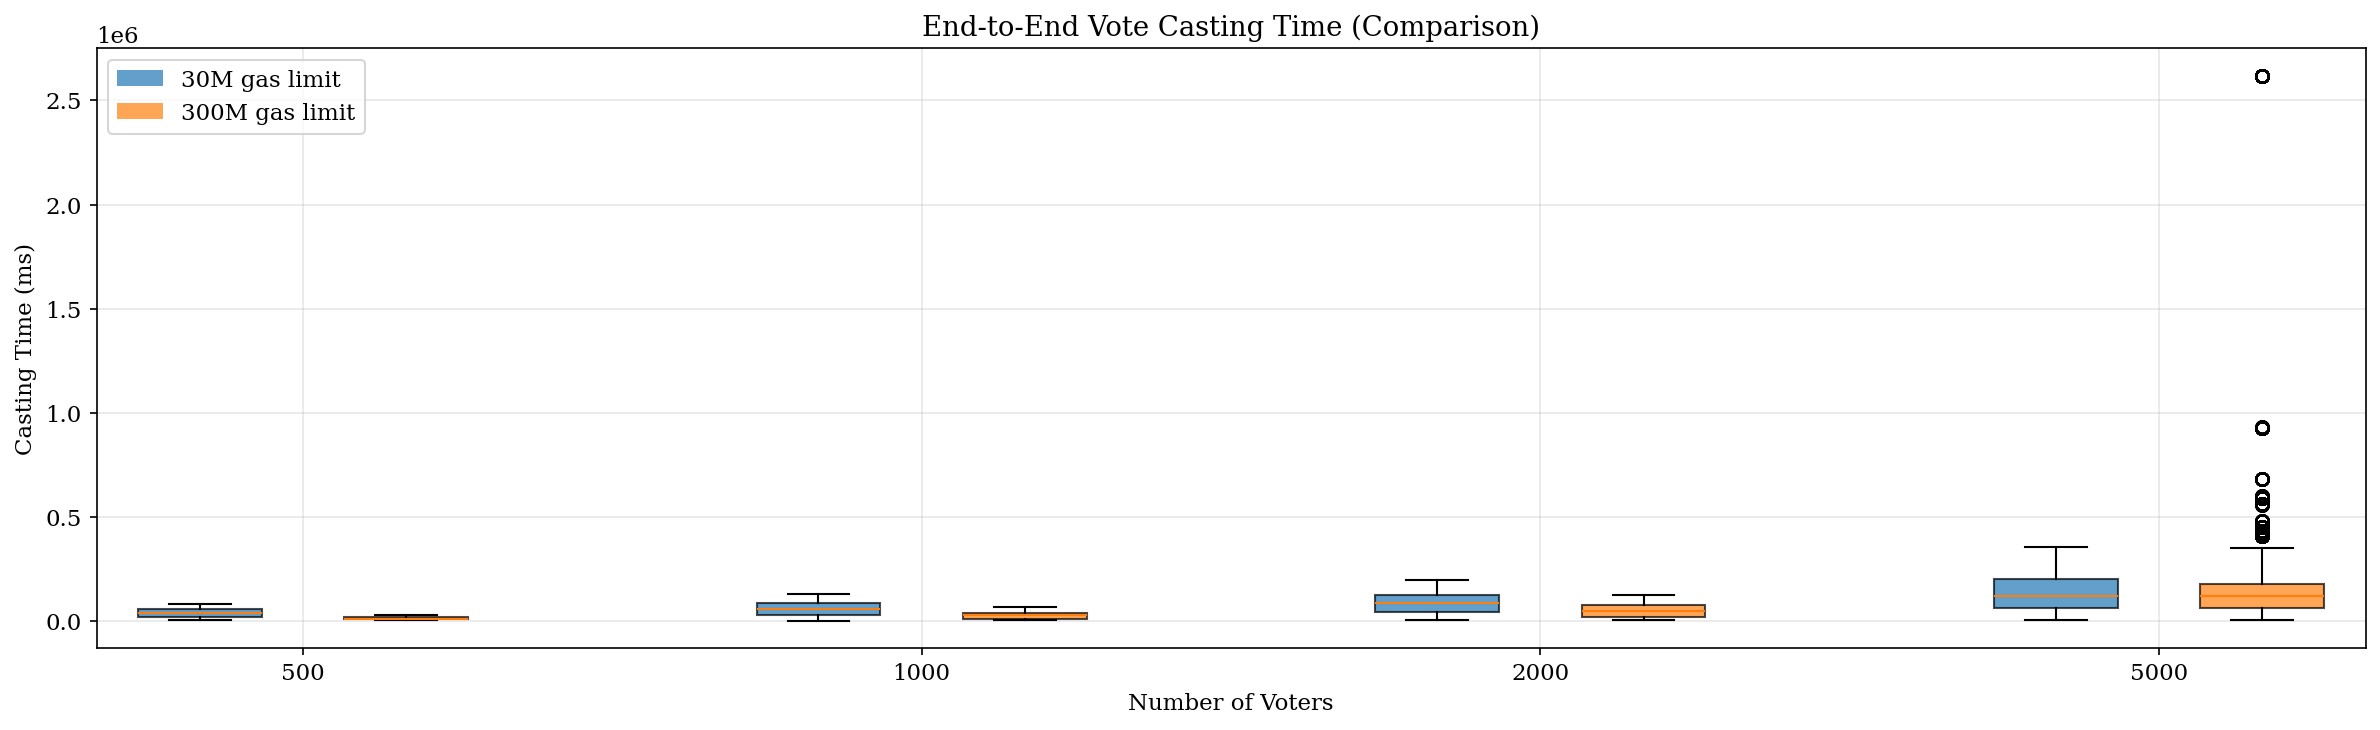

In [6]:
if not successful.empty:
    fig, ax = plt.subplots(figsize=(max(8, 2 * len(scale_points) * n_runs), 5))
    tick_positions = []
    tick_labels_list = []
    pos = 0

    for sp in scale_points:
        for run_label in run_labels:
            data = successful[(successful['scale_point'] == sp) & (successful['run'] == run_label)]['casting_time_ms'].dropna()
            if not data.empty:
                bp = ax.boxplot([data], positions=[pos], widths=0.6, patch_artist=True)
                for patch in bp['boxes']:
                    patch.set_facecolor(RUN_COLORS[run_label])
                    patch.set_alpha(0.7)
            pos += 1
        tick_positions.append(pos - n_runs / 2 - 0.5)
        tick_labels_list.append(str(sp))
        pos += 1

    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels_list)
    ax.set_xlabel('Number of Voters')
    ax.set_ylabel('Casting Time (ms)')
    ax.set_title('End-to-End Vote Casting Time (Comparison)')
    legend_elements = [Patch(facecolor=RUN_COLORS[l], alpha=0.7, label=l) for l in run_labels]
    ax.legend(handles=legend_elements)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'fig_casting_time_comparison.eps', format='eps')
    plt.show()

## 4. Blockchain Performance Comparison

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


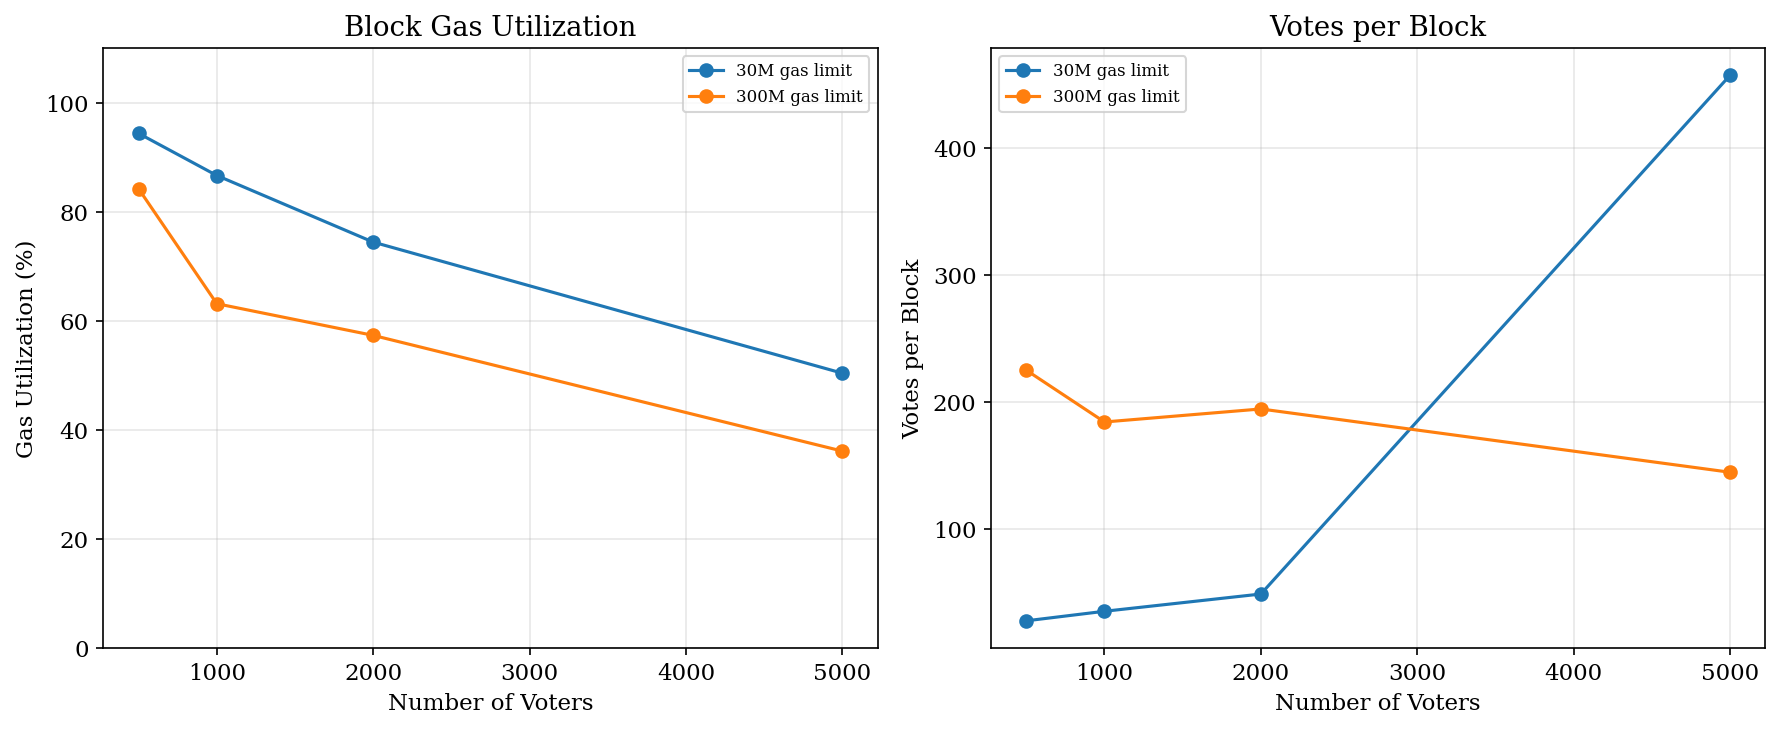

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for r in combined_results:
    label = r['_label']
    color = RUN_COLORS[label]
    blocks = []
    for sp in r['scalePoints']:
        for rep in sp['repetitions']:
            t = rep.get('throughput')
            if t:
                blocks.append({'voters': sp['voters'], 'gasUtil': t['avgGasUtil'], 'vpb': t['avgVotesPerBlock']})
    if blocks:
        bdf = pd.DataFrame(blocks)
        means = bdf.groupby('voters').mean()
        ax1.plot(means.index, means['gasUtil'] * 100, 'o-', color=color, label=label, markersize=6)
        ax2.plot(means.index, means['vpb'], 'o-', color=color, label=label, markersize=6)

ax1.set_xlabel('Number of Voters')
ax1.set_ylabel('Gas Utilization (%)')
ax1.set_title('Block Gas Utilization')
ax1.set_ylim(0, 110)
ax1.legend(fontsize=8)
ax2.set_xlabel('Number of Voters')
ax2.set_ylabel('Votes per Block')
ax2.set_title('Votes per Block')
ax2.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_blockchain_comparison.eps', format='eps')
plt.show()

## 5. Summary Table

In [8]:
rows = []
for sp_voters in scale_points:
    row = {'Voters': sp_voters}
    for r in combined_results:
        label = r['_label']
        sp_data = next((sp for sp in r['scalePoints'] if sp['voters'] == sp_voters), None)
        if sp_data:
            agg = sp_data.get('aggregated', {})
            for metric, col_name in [('tps', 'TPS'), ('inclusionDelay', 'Incl.(ms)')]:
                m = agg.get(metric, {})
                if m:
                    row[f"{label} {col_name}"] = f"{m['mean']:.1f}±{m['ci95']:.1f}"
                else:
                    row[f"{label} {col_name}"] = '-'
            failures = agg.get('failures', {})
            row[f"{label} OK"] = f"{failures.get('successes', 0)}/{failures.get('total', 0)}"
        else:
            row[f"{label} TPS"] = '-'
            row[f"{label} Incl.(ms)"] = '-'
            row[f"{label} OK"] = '-'
    rows.append(row)

summary = pd.DataFrame(rows)
print(summary.to_string(index=False))

 Voters 30M gas limit TPS 30M gas limit Incl.(ms) 30M gas limit OK 300M gas limit TPS 300M gas limit Incl.(ms) 300M gas limit OK
    500           7.4±0.4          38285.4±1856.4        5000/5000           42.5±7.5           12395.2±1157.2         5000/5000
   1000           9.2±0.5          58002.5±2858.8      10000/10000           22.7±2.0           25959.2±2257.6       10000/10000
   2000          12.5±0.8          86115.2±5088.0      20000/20000           21.6±2.3           49465.1±4686.4       20000/20000
   5000       113.7±179.5        130853.3±26307.7      46853/48125           14.4±7.1          123198.2±8012.5       46033/46223


## 6. Consensus Latency Comparison
Node consensus latency (inclusion delay) across configurations and scale points.

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


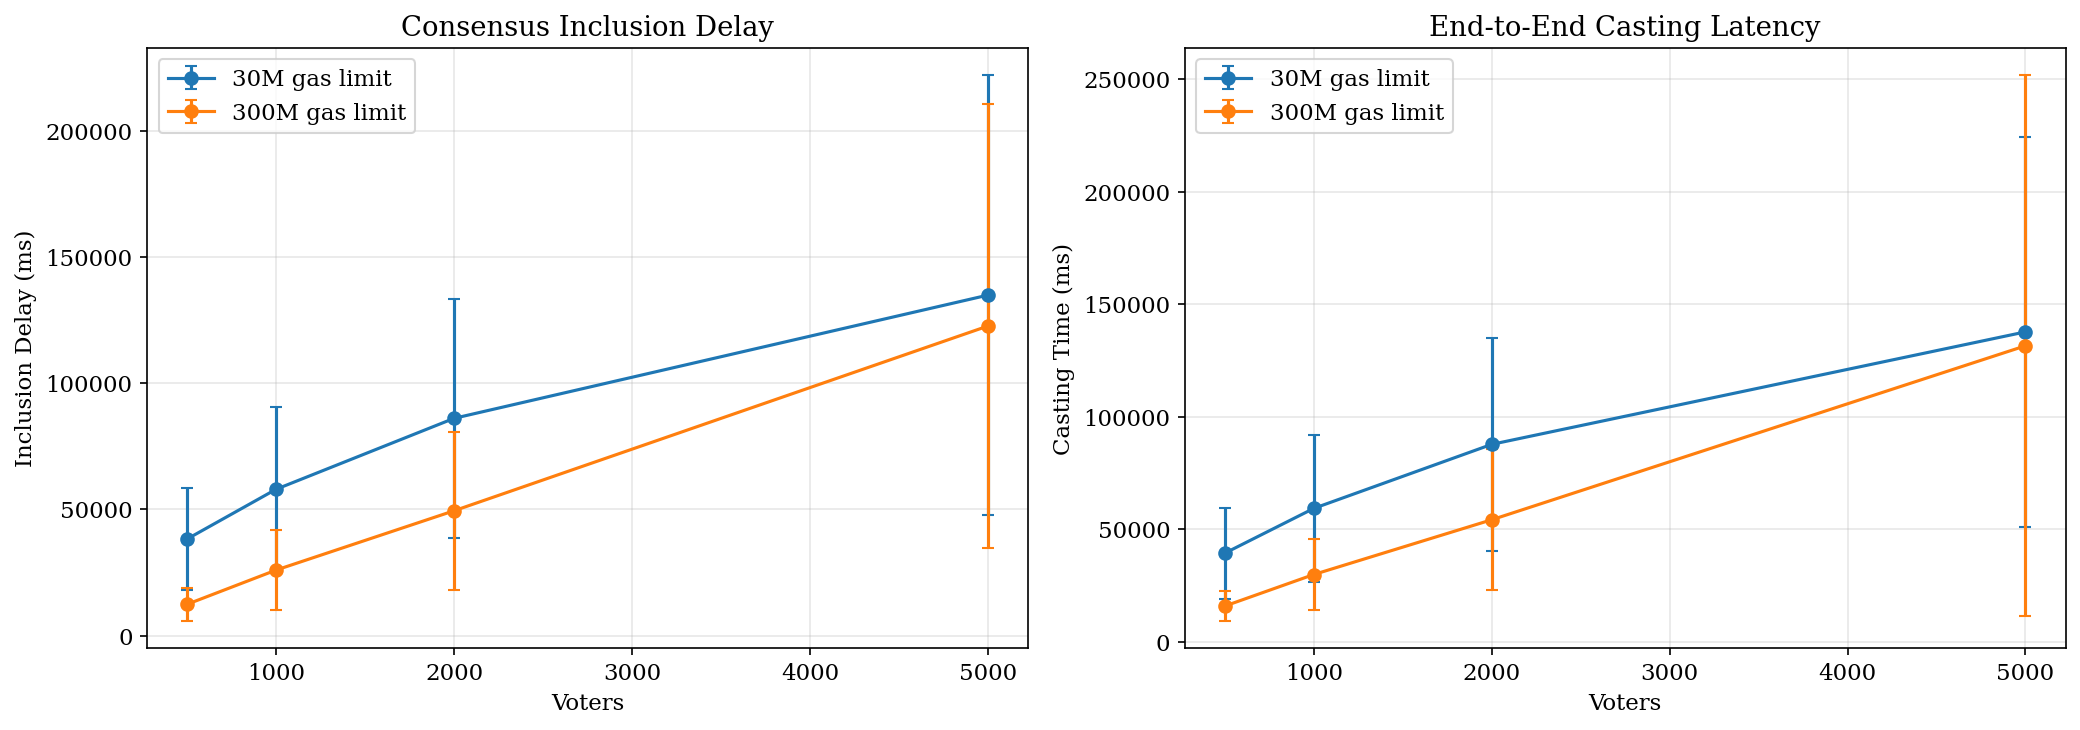

In [9]:
successful = combined_df[combined_df['status'] == 'success'].copy()

if not successful.empty and 'inclusion_delay_ms' in successful.columns:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Inclusion delay by run and scale point
    for i, label in enumerate(run_labels):
        sub = successful[successful['run'] == label]
        stats = sub.groupby('scale_point')['inclusion_delay_ms'].agg(['mean', 'std'])
        ax1.errorbar(stats.index, stats['mean'], yerr=stats['std'],
                     label=label, color=RUN_COLORS[label], marker='o', capsize=3)
    ax1.set_xlabel('Voters')
    ax1.set_ylabel('Inclusion Delay (ms)')
    ax1.set_title('Consensus Inclusion Delay')
    ax1.legend()

    # Casting time by run and scale point
    for i, label in enumerate(run_labels):
        sub = successful[successful['run'] == label]
        stats = sub.groupby('scale_point')['casting_time_ms'].agg(['mean', 'std'])
        ax2.errorbar(stats.index, stats['mean'], yerr=stats['std'],
                     label=label, color=RUN_COLORS[label], marker='o', capsize=3)
    ax2.set_xlabel('Voters')
    ax2.set_ylabel('Casting Time (ms)')
    ax2.set_title('End-to-End Casting Latency')
    ax2.legend()

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'fig_consensus_latency_comparison.eps', format='eps')
    plt.savefig(OUTPUT_DIR / 'fig_consensus_latency_comparison.png', dpi=150)
    plt.show()
